<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/redes_neuronales_uci_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ¿Qué hace este bloque?
# Instalamos e importamos todas las herramientas necesarias.
# Es como preparar los ingredientes antes de cocinar.

!pip install ucimlrepo -q  # Descarga la librería del repositorio UCI

import numpy as np              # Matemáticas con matrices (la base de todo)
import pandas as pd             # Para manejar tablas de datos
import matplotlib.pyplot as plt # Para hacer gráficas
import seaborn as sns           # Gráficas más estilizadas
from sklearn.model_selection import train_test_split  # Divide los datos en conjuntos
from sklearn.preprocessing import StandardScaler      # Normaliza los datos
from sklearn.metrics import (classification_report, confusion_matrix,
                             r2_score, mean_absolute_error, mean_squared_error)
import torch                            # Framework principal de deep learning
import torch.nn as nn                   # Bloques para construir redes neuronales
import torch.optim as optim             # Algoritmos de optimización (aprendizaje)
from torch.utils.data import Dataset, DataLoader  # Manejo de datos en mini-lotes
from ucimlrepo import fetch_ucirepo    # Descarga el dataset Wine Quality UCI

# Fijamos semillas para que los resultados sean reproducibles cada vez que ejecutes
torch.manual_seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
print("¡Todo listo! Las librerías se importaron correctamente.")
print(f"Versión de PyTorch: {torch.__version__}")


¡Todo listo! Las librerías se importaron correctamente.
Versión de PyTorch: 2.10.0+cpu


# Análisis Exploratorio de Datos (EDA)

## ¿Qué vamos a aprender aquí?

Antes de entrenar cualquier red neuronal, necesitamos conocer nuestros datos.
Es como leer la receta completa antes de cocinar: entender qué tenemos y cómo está organizado.

El dataset **Wine Quality** (Repositorio UCI de Machine Learning) contiene
mediciones físico-químicas de vinos portugueses y una puntuación de calidad del 0 al 10.

- **11 características numéricas**: acidez, sulfatos, nivel de alcohol, pH, etc.
- **Target para clasificación**: binario — vino *bueno* (calidad ≥ 6 → 1) o *malo* (< 6 → 0)
- **Target para regresión**: el score original de calidad como número continuo (0–10)

Vamos a explorar distribuciones, correlaciones y diferencias entre clases para
entender qué variables son más importantes para predecir la calidad del vino.


In [2]:
# ¿Qué hace este bloque?
# Descargamos el dataset Wine Quality directamente desde el repositorio UCI.

dataset_vinos = fetch_ucirepo(id=186)   # id=186 identifica Wine Quality en UCI

# Separamos características (X) y etiquetas (y)
X_df = dataset_vinos.data.features   # Tabla con las 11 propiedades del vino
y_df = dataset_vinos.data.targets    # Columna con la puntuación de calidad

print("Dimensiones de las características:", X_df.shape)
print("Dimensiones del target:            ", y_df.shape)
print("\nColumnas disponibles:", list(X_df.columns))
print("\nTipo de dato de cada columna:")
print(X_df.dtypes)


Dimensiones de las características: (6497, 11)
Dimensiones del target:             (6497, 1)

Columnas disponibles: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Tipo de dato de cada columna:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object


In [3]:
# ¿Qué hace este bloque?
# Calculamos estadísticas básicas para entender el rango y dispersión de cada feature.
# La media, desviación estándar y percentiles nos dicen qué tan "esparcidos" están los valores.

print("=== Estadísticas Descriptivas de las Características ===")
display(X_df.describe().round(3))


=== Estadísticas Descriptivas de las Características ===


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900


In [4]:
# ¿Qué hace este bloque?
# Preparamos dos versiones del target:
#   1. Continuo (para regresión): el score tal como viene (0-10)
#   2. Binario  (para clasificación): 1=bueno si score>=6, 0=malo si score<6
# También convertimos los datos a float32, el formato que usa PyTorch.

# Target continuo: útil para predecir el score exacto (tarea de regresión)
puntuacion_real = y_df.values.flatten().astype("float32")

# Target binario: umbral de 6 — puntuación >= 6 se considera buen vino
etiqueta_binaria = (puntuacion_real >= 6).astype("float32")

# Convertimos las features a numpy
X_np = X_df.values.astype("float32")
numero_features = X_np.shape[1]
nombres_features = list(X_df.columns)

print(f"Regresión  — mínimo: {puntuacion_real.min():.1f}  máximo: {puntuacion_real.max():.1f}  media: {puntuacion_real.mean():.2f}")
print(f"Clasificación — Malo(0): {(etiqueta_binaria==0).sum()}  Bueno(1): {(etiqueta_binaria==1).sum()}")
print(f"Proporción de vinos buenos: {etiqueta_binaria.mean():.2%}")

# Alias cortos usados a lo largo del notebook
y_reg = puntuacion_real
y_clf = etiqueta_binaria
n_features = numero_features
feature_names = nombres_features


Regresión  — mínimo: 3.0  máximo: 9.0  media: 5.82
Clasificación — Malo(0): 2384  Bueno(1): 4113
Proporción de vinos buenos: 63.31%


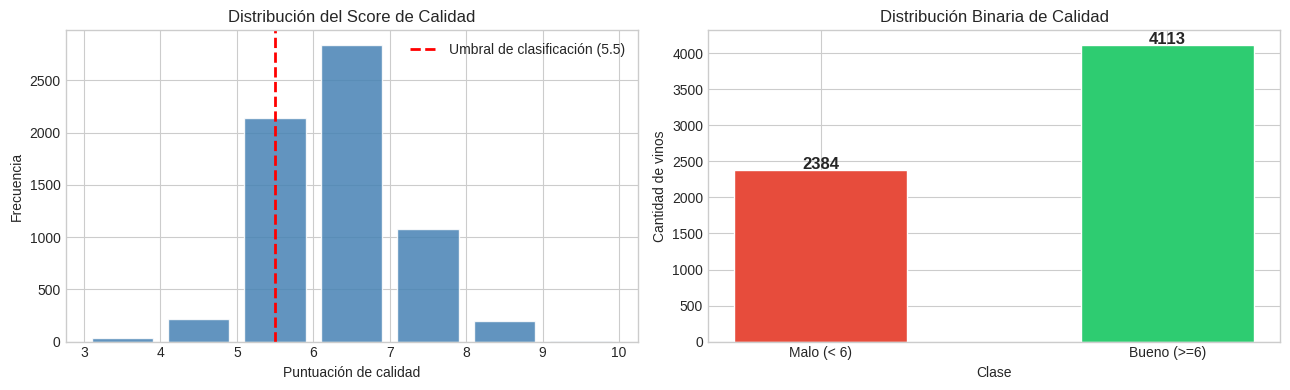

In [5]:
# ¿Qué hace este bloque?
# Visualizamos cómo se distribuyen las puntuaciones y cuántos vinos hay de cada clase.
# Detectar desbalance de clases (muchos de un tipo, pocos del otro) es importante
# porque puede hacer que el modelo aprenda a favorecer la clase más frecuente.

figura, ejes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico izquierdo: histograma de puntuaciones (0-10)
ejes[0].hist(y_reg, bins=range(3, 11), color="steelblue",
             edgecolor="white", alpha=0.85, rwidth=0.8)
ejes[0].axvline(x=5.5, color="red", linestyle="--", lw=2,
                label="Umbral de clasificación (5.5)")
ejes[0].set_xlabel("Puntuación de calidad")
ejes[0].set_ylabel("Frecuencia")
ejes[0].set_title("Distribución del Score de Calidad")
ejes[0].legend()

# Gráfico derecho: barras de la clasificación binaria
conteos_clases = [(y_clf == 0).sum(), (y_clf == 1).sum()]
barras = ejes[1].bar(["Malo (< 6)", "Bueno (>=6)"], conteos_clases,
                     color=["#e74c3c", "#2ecc71"], edgecolor="white", width=0.5)
for barra, cantidad in zip(barras, conteos_clases):
    ejes[1].text(barra.get_x() + barra.get_width() / 2,
                 barra.get_height() + 15,
                 str(cantidad), ha="center", fontweight="bold", fontsize=12)
ejes[1].set_xlabel("Clase")
ejes[1].set_ylabel("Cantidad de vinos")
ejes[1].set_title("Distribución Binaria de Calidad")

plt.tight_layout()
plt.show()


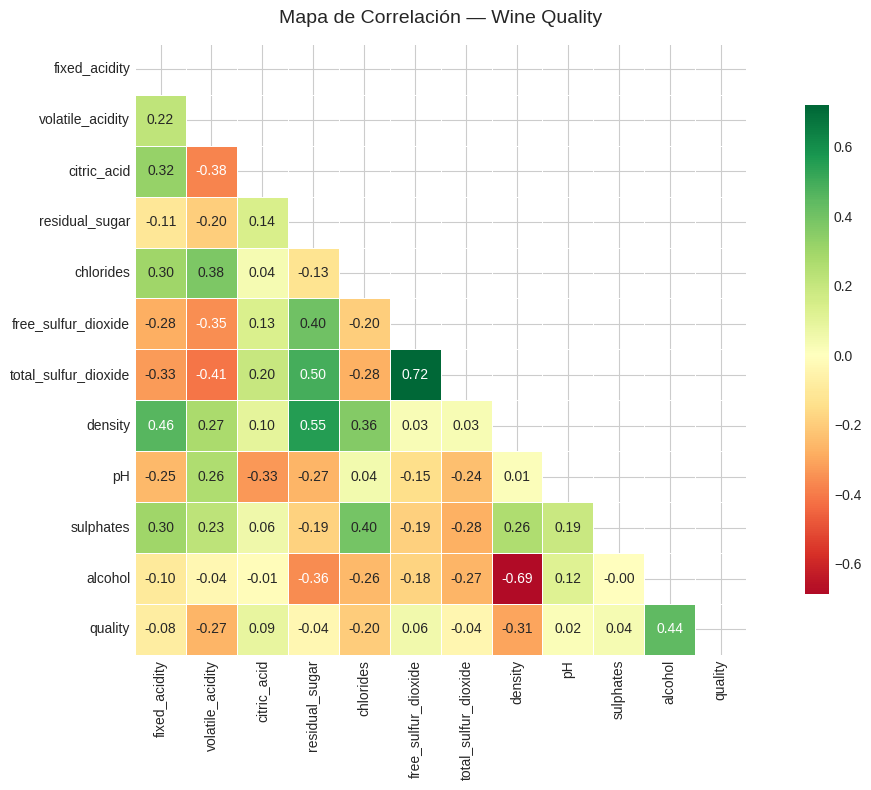

Top features por correlación con la calidad del vino:
alcohol             0.444319
density             0.305858
volatile_acidity    0.265699
chlorides           0.200666
citric_acid         0.085532
fixed_acidity       0.076743


In [6]:
# ¿Qué hace este bloque?
# Calculamos la correlación entre todas las variables.
# Una correlación alta (+1 o -1) indica que dos variables se mueven juntas.
# Esto nos ayuda a identificar qué features son más informativas para la red.

# Añadimos la calidad al dataframe para correlacionarla con las features
df_correlacion = X_df.copy()
df_correlacion["quality"] = y_reg
matriz_correlacion = df_correlacion.corr()

# La máscara triangular evita mostrar la misma correlación dos veces
mascara_triangulo = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

figura, eje = plt.subplots(figsize=(12, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mascara_triangulo, ax=eje, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
eje.set_title("Mapa de Correlación — Wine Quality", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Las features con mayor correlación son las más útiles para el modelo
correlacion_con_calidad = (df_correlacion.corr()["quality"]
                           .drop("quality").abs()
                           .sort_values(ascending=False))
print("Top features por correlación con la calidad del vino:")
print(correlacion_con_calidad.head(6).to_string())


/tmp/ipykernel_1946/3210340208.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ejes[i].boxplot([datos_vinos_malos, datos_vinos_buenos],
/tmp/ipykernel_1946/3210340208.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ejes[i].boxplot([datos_vinos_malos, datos_vinos_buenos],
/tmp/ipykernel_1946/3210340208.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ejes[i].boxplot([datos_vinos_malos, datos_vinos_buenos],
/tmp/ipykernel_1946/3210340208.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

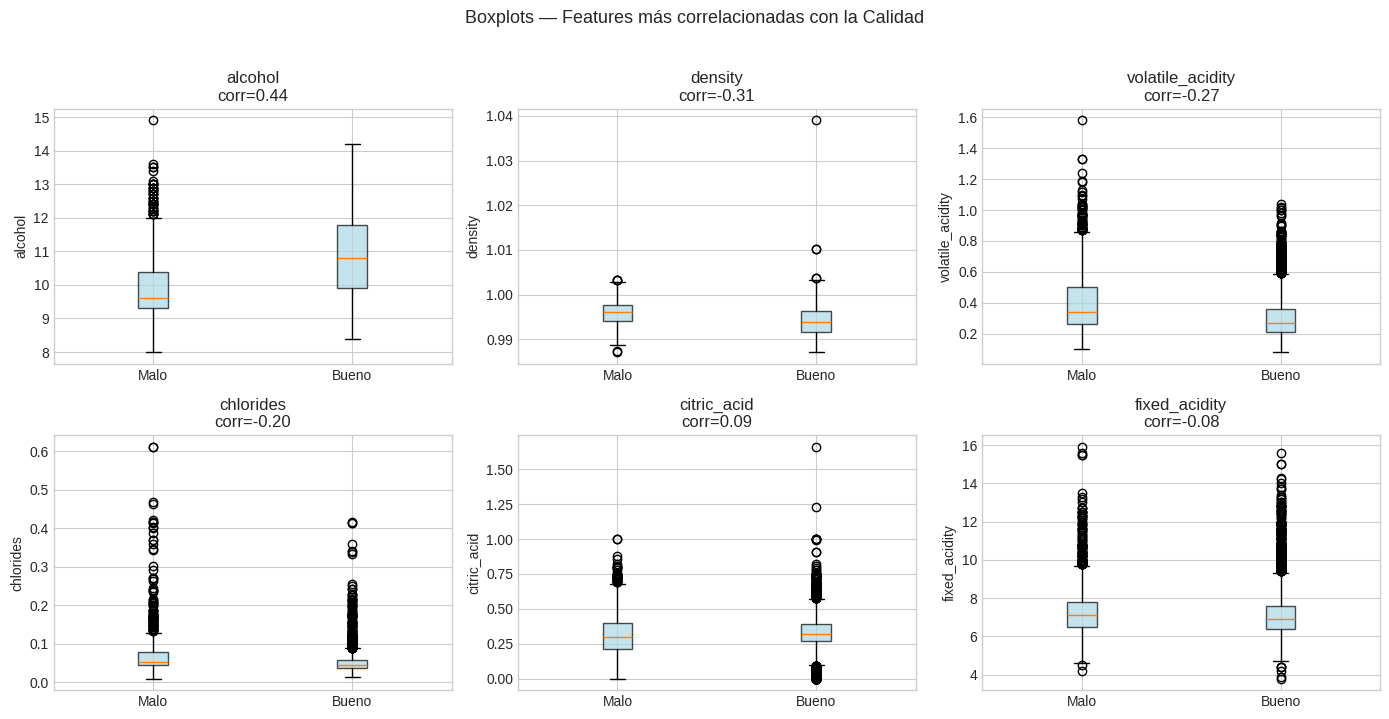

In [7]:
# ¿Qué hace este bloque?
# Los boxplots muestran si una feature toma valores distintos en vinos buenos vs malos.
# Si las cajas no se superponen, esa feature es muy útil para distinguir las clases.

# Seleccionamos las 6 features más correlacionadas con la calidad
df_para_boxplot = X_df.copy()
df_para_boxplot["quality"] = y_reg
top_6_features = (df_para_boxplot.corr()["quality"]
                  .drop("quality").abs()
                  .sort_values(ascending=False)
                  .head(6).index.tolist())

figura, ejes = plt.subplots(2, 3, figsize=(14, 7))
ejes = ejes.flatten()  # Aplanamos para iterar fácilmente

for i, nombre_feature in enumerate(top_6_features):
    datos_vinos_malos  = X_df.loc[y_clf == 0, nombre_feature]
    datos_vinos_buenos = X_df.loc[y_clf == 1, nombre_feature]
    ejes[i].boxplot([datos_vinos_malos, datos_vinos_buenos],
                    labels=["Malo", "Bueno"], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7))
    valor_corr = df_para_boxplot.corr()["quality"][nombre_feature]
    ejes[i].set_title(f"{nombre_feature}\ncorr={valor_corr:.2f}")
    ejes[i].set_ylabel(nombre_feature)

plt.suptitle("Boxplots — Features más correlacionadas con la Calidad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
# FASE 1 — Fundamentos Matemáticos (NumPy puro)

## ¿Qué vamos a aprender aquí?

En esta fase vamos a construir una red neuronal **desde cero**, sin usar PyTorch ni TensorFlow.
¿Por qué? Porque si entiendes cada operación a mano, luego entenderás exactamente
qué hacen los frameworks cuando lo hacen automáticamente.

Es como aprender a sumar a mano antes de usar una calculadora.

Los 5 conceptos que vamos a implementar manualmente:

1. **Funciones de activación**: transforman la suma de entradas en la salida de una neurona.
2. **Forward pass (paso hacia adelante)**: la red recibe datos y genera una predicción.
3. **Función de pérdida**: mide qué tan equivocada está la predicción.
4. **Backpropagation (propagación hacia atrás)**: calcula cómo ajustar cada peso para reducir el error.
5. **Descenso del gradiente**: actualiza los pesos en la dirección que minimiza el error.


## 1.1 Funciones de Activación

Las funciones de activación deciden si una neurona "se enciende" o no ante una señal de entrada.
Sin ellas, la red sería solo multiplicaciones de matrices (una función lineal), sin capacidad
de aprender patrones complejos.

### Sigmoide
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

**En palabras simples:** aplasta cualquier número al rango (0, 1). Perfecta para la capa de salida
cuando queremos una probabilidad ("¿qué tan probable es que este vino sea bueno?").

### ReLU (Rectified Linear Unit)
$$\text{ReLU}(z) = \max(0, z), \qquad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

**En palabras simples:** si el valor es positivo lo deja pasar; si es negativo lo convierte en cero.
Es la más usada en capas ocultas porque aprende rápido y evita el problema del gradiente evanescente.

### Softmax
$$\text{softmax}(z_i) = \frac{e^{z_i - \max z}}{\sum_j e^{z_j - \max z}}$$

**En palabras simples:** convierte un vector de números en probabilidades que suman 1.
Útil cuando hay más de dos clases posibles.


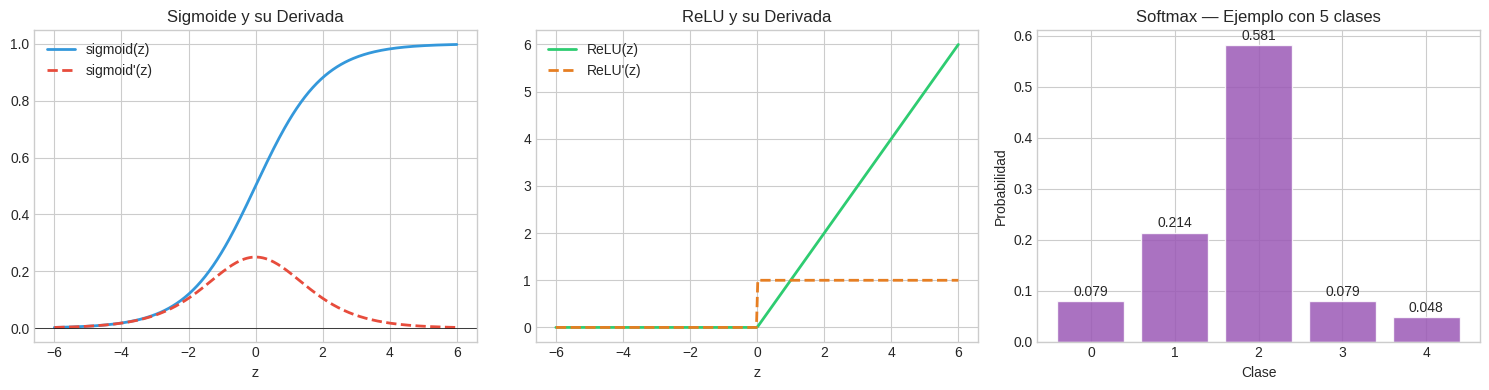

In [8]:
# ¿Qué hace este bloque?
# Definimos las funciones de activación como funciones de Python.
# Cada una tiene su versión normal y su derivada (necesaria para backprop).

def sigmoid(z):
    """Aplasta cualquier número al rango (0, 1)."""
    # np.clip evita desbordamiento numérico con valores muy grandes o pequeños
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivada(z):
    """Derivada de la sigmoide: sigma(z) * (1 - sigma(z))."""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """Deja pasar los valores positivos; bloquea los negativos (los convierte en cero)."""
    return np.maximum(0, z)

def relu_derivada(z):
    """Derivada de ReLU: 1 donde z>0, 0 en cualquier otro caso."""
    return (z > 0).astype(np.float32)

def softmax(z):
    """Convierte un vector de scores en probabilidades que suman 1.
    El truco de restar max(z) evita errores numéricos por números muy grandes."""
    z_estable = z - np.max(z, axis=1, keepdims=True)
    exponenciales = np.exp(z_estable)
    return exponenciales / np.sum(exponenciales, axis=1, keepdims=True)


# --- Visualización de las tres funciones ---
valores_z = np.linspace(-6, 6, 300)
figura, ejes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Sigmoide y su derivada
ejes[0].plot(valores_z, sigmoid(valores_z), color="#3498db", lw=2, label="sigmoid(z)")
ejes[0].plot(valores_z, sigmoid_derivada(valores_z), color="#e74c3c", lw=2,
             linestyle="--", label="sigmoid'(z)")
ejes[0].set_title("Sigmoide y su Derivada")
ejes[0].set_xlabel("z")
ejes[0].legend()
ejes[0].axhline(0, color="black", lw=0.5)

# Gráfico 2: ReLU y su derivada
ejes[1].plot(valores_z, relu(valores_z), color="#2ecc71", lw=2, label="ReLU(z)")
ejes[1].plot(valores_z, relu_derivada(valores_z), color="#e67e22", lw=2,
             linestyle="--", label="ReLU'(z)")
ejes[1].set_title("ReLU y su Derivada")
ejes[1].set_xlabel("z")
ejes[1].legend()

# Gráfico 3: Softmax en un ejemplo de 5 clases
ejemplo_scores = np.array([[1.0, 2.0, 3.0, 1.0, 0.5]])
probabilidades = softmax(ejemplo_scores)[0]
ejes[2].bar(range(len(probabilidades)), probabilidades,
            color="#9b59b6", edgecolor="white", alpha=0.85)
ejes[2].set_title("Softmax — Ejemplo con 5 clases")
ejes[2].set_xlabel("Clase")
ejes[2].set_ylabel("Probabilidad")
for i, p in enumerate(probabilidades):
    ejes[2].text(i, p + 0.01, f"{p:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


## 1.2 Red MLP desde cero

### Forward Pass (paso hacia adelante)
Para cada capa $l$ de la red, calculamos:
$$z^{[l]} = a^{[l-1]} W^{[l]} + b^{[l]}, \qquad a^{[l]} = g^{[l]}(z^{[l]})$$

**En palabras simples:** multiplicamos las activaciones de la capa anterior por los pesos,
sumamos el sesgo, y aplicamos la función de activación. Repetimos capa por capa hasta la salida.

### Función de Pérdida BCE (Binary Cross-Entropy)
$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \bigl[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \bigr]$$

**En palabras simples:** mide qué tan equivocada está la predicción. Cuanto más cerca de 0, mejor aprende la red.

### Backpropagation (propagación hacia atrás)
$$\frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{1}{m} (a^{[l-1]})^\top \cdot \delta^{[l]}, \qquad \delta^{[l]} = \delta^{[l+1]} (W^{[l+1]})^\top \odot g'^{[l]}(z^{[l]})$$

**En palabras simples:** calculamos cuánto contribuye cada peso al error total usando la regla
de la cadena del cálculo diferencial. Vamos "de atrás hacia adelante", capa por capa.

### Inicialización Xavier/Glorot
$$W \sim \mathcal{N}\!\left(0,\; \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}\right)$$

**En palabras simples:** los pesos iniciales deben ser pequeños y proporcionales al tamaño de cada capa.
Esto evita que las señales crezcan o desaparezcan al inicio del entrenamiento.


In [9]:
# ¿Qué hace este bloque?
# Definimos la clase MLPNumpy: nuestra red neuronal hecha completamente a mano.
# Tiene cuatro operaciones principales:
#   - forward:        recorre la red capa por capa y genera una predicción
#   - compute_loss:   mide el error de la predicción
#   - backward:       calcula los gradientes (cuánto cambiar cada peso)
#   - update_weights: aplica los cambios a los pesos

class MLPNumpy:
    """Red neuronal MLP construida desde cero con NumPy.
    Capas ocultas usan ReLU; la capa de salida usa Sigmoide para clasificación binaria."""

    def __init__(self, tamanos_capas):
        """Crea la red e inicializa pesos con el método Xavier.
        tamanos_capas: lista con neuronas por capa, ej. [11, 64, 32, 1]"""
        self.tamanos_capas = tamanos_capas
        self.numero_capas  = len(tamanos_capas) - 1

        # Inicializamos pesos (W) y sesgos (b) para cada capa
        self.W = []  # Matrices de pesos — se actualizan en cada paso
        self.b = []  # Vectores de sesgo — también se actualizan
        for i in range(self.numero_capas):
            neuronas_entrada = tamanos_capas[i]
            neuronas_salida  = tamanos_capas[i + 1]
            # Escala Xavier: garantiza que los gradientes no se desvanezcan ni exploten
            escala_xavier = np.sqrt(2.0 / (neuronas_entrada + neuronas_salida))
            self.W.append(
                np.random.randn(neuronas_entrada, neuronas_salida).astype(np.float32) * escala_xavier
            )
            self.b.append(np.zeros((1, neuronas_salida), dtype=np.float32))

        # Guardamos activaciones y pre-activaciones durante forward (las necesita backward)
        self.activaciones     = []
        self.pre_activaciones = []
        self.gradiente_W = [None] * self.numero_capas
        self.gradiente_b = [None] * self.numero_capas

    def forward(self, X):
        """Recorre la red capa por capa y calcula la predicción.
        X tiene forma (batch, n_features). Devuelve probabilidades en (0, 1)."""
        self.activaciones     = [X]   # La activación de capa 0 son los datos crudos
        self.pre_activaciones = []
        activacion_actual     = X

        for i in range(self.numero_capas):
            # Producto matricial: activación × pesos + sesgo
            z = activacion_actual @ self.W[i] + self.b[i]
            self.pre_activaciones.append(z)

            # Capas ocultas usan ReLU; la capa de salida usa Sigmoide
            if i < self.numero_capas - 1:
                activacion_actual = relu(z)
            else:
                activacion_actual = sigmoid(z)
            self.activaciones.append(activacion_actual)

        return self.activaciones[-1]

    def compute_loss(self, prediccion, etiqueta_real):
        """Calcula el error BCE: cuanto más cercano a 0, mejor está la red."""
        eps = 1e-8  # Evita log(0) que daría infinito
        prediccion_segura = np.clip(prediccion, eps, 1.0 - eps)
        return -np.mean(
            etiqueta_real * np.log(prediccion_segura) +
            (1 - etiqueta_real) * np.log(1 - prediccion_segura)
        )

    def backward(self, X, etiqueta_real):
        """Calcula cuánto debe cambiar cada peso para reducir el error.
        Usa la regla de la cadena (backpropagation) recorriendo la red al revés."""
        numero_muestras = X.shape[0]

        # Para BCE + Sigmoide, el gradiente de la capa de salida simplifica elegantemente a:
        delta = (self.activaciones[-1] - etiqueta_real) / numero_muestras

        # Recorremos las capas de atrás hacia adelante
        for i in range(self.numero_capas - 1, -1, -1):
            activacion_previa    = self.activaciones[i]
            self.gradiente_W[i]  = activacion_previa.T @ delta
            self.gradiente_b[i]  = np.sum(delta, axis=0, keepdims=True)

            if i > 0:
                delta = (delta @ self.W[i].T) * relu_derivada(self.pre_activaciones[i - 1])

    def update_weights(self, tasa_aprendizaje):
        """Ajusta los pesos un paso en la dirección que reduce el error.
        tasa_aprendizaje: controla el tamaño de cada actualización."""
        for i in range(self.numero_capas):
            self.W[i] -= tasa_aprendizaje * self.gradiente_W[i]
            self.b[i] -= tasa_aprendizaje * self.gradiente_b[i]

    def predecir(self, X):
        """Clasifica cada muestra: 1 (bueno) si prob>=0.5, 0 (malo) si prob<0.5."""
        return (self.forward(X) >= 0.5).astype(np.float32)

    def exactitud(self, X, etiquetas):
        """Calcula el porcentaje de predicciones correctas."""
        return float(np.mean(self.predecir(X) == etiquetas))

    # Alias en inglés para compatibilidad con código posterior
    def predict(self, X):
        return self.predecir(X)

    def accuracy(self, X, y):
        return self.exactitud(X, y)


print("Clase MLPNumpy definida correctamente.")


Clase MLPNumpy definida correctamente.


In [10]:
# ¿Qué hace este bloque?
# Dividimos los datos en tres conjuntos:
#   - Entrenamiento (70%): la red aprende con estos datos
#   - Validación   (10%): monitoreamos si el modelo generaliza bien
#   - Prueba       (20%): evaluamos el rendimiento final con datos completamente nuevos
# Luego normalizamos para que todas las features estén en la misma escala.

# Creamos un arreglo con todos los índices del dataset
todos_los_indices = np.arange(len(X_np))

# Primera división: separamos el 20% para prueba final
indices_temporales, indices_prueba = train_test_split(
    todos_los_indices, test_size=0.20, random_state=42, stratify=y_clf)

# Segunda división: del 80% restante, sacamos ~10% para validación
indices_entren, indices_val = train_test_split(
    indices_temporales, test_size=0.125, random_state=42,
    stratify=y_clf[indices_temporales])

# Construimos los subconjuntos de features e etiquetas
X_train_f1 = X_np[indices_entren]
X_val_f1   = X_np[indices_val]
X_test_f1  = X_np[indices_prueba]

y_train_f1 = y_clf[indices_entren].reshape(-1, 1)
y_val_f1   = y_clf[indices_val].reshape(-1, 1)
y_test_f1  = y_clf[indices_prueba].reshape(-1, 1)

# Normalizamos los datos para que todas las features estén en la misma escala.
# IMPORTANTE: el normalizador aprende la media/desviación SOLO del entrenamiento
# y luego aplica esa misma transformación a validación y prueba (no hacemos trampa).
normalizador_f1 = StandardScaler()
X_train_f1 = normalizador_f1.fit_transform(X_train_f1).astype(np.float32)
X_val_f1   = normalizador_f1.transform(X_val_f1).astype(np.float32)
X_test_f1  = normalizador_f1.transform(X_test_f1).astype(np.float32)

print(f"Entrenamiento: {X_train_f1.shape}  Validación: {X_val_f1.shape}  Prueba: {X_test_f1.shape}")


Entrenamiento: (4547, 11)  Validación: (650, 11)  Prueba: (1300, 11)


In [11]:
# ¿Qué hace este bloque?
# Entrenamos la red durante 200 épocas. Cada época = la red ve todos los datos
# de entrenamiento una vez, ajusta los pesos, y luego evaluamos en validación.
# Guardamos pérdida y exactitud de entrenamiento Y validación en cada época.

# Hiperparámetros: decisiones que tomamos antes de entrenar
ARQUITECTURA_NP         = [n_features, 64, 32, 1]  # [entrada, capa1, capa2, salida]
EPOCAS_NP               = 200
TASA_APRENDIZAJE_NP     = 0.05

# Creamos la red y guardamos los pesos iniciales para visualizarlos más adelante
mlp_np = MLPNumpy(ARQUITECTURA_NP)
pesos_iniciales_W1 = mlp_np.W[0].copy()

# Listas para registrar el progreso época por época
historial_perdida       = []   # Pérdida de entrenamiento
historial_exactitud     = []   # Exactitud de entrenamiento
historial_perdida_val   = []   # Pérdida en validación
historial_exactitud_val = []   # Exactitud en validación

print("La red está comenzando a aprender... esto puede tardar unos segundos.")

for epoca in range(EPOCAS_NP):
    # Paso 1: Forward — la red genera predicciones con los datos actuales
    prediccion_entren = mlp_np.forward(X_train_f1)
    perdida_entren    = mlp_np.compute_loss(prediccion_entren, y_train_f1)

    # Paso 2: Backward — calculamos cuánto debe cambiar cada peso
    mlp_np.backward(X_train_f1, y_train_f1)

    # Paso 3: Actualización — aplicamos los cambios a los pesos
    mlp_np.update_weights(TASA_APRENDIZAJE_NP)

    # Registramos métricas de entrenamiento
    historial_perdida.append(perdida_entren)
    historial_exactitud.append(mlp_np.exactitud(X_train_f1, y_train_f1))

    # Evaluamos en validación (sin actualizar pesos — solo miramos)
    prediccion_val  = mlp_np.forward(X_val_f1)
    perdida_val     = mlp_np.compute_loss(prediccion_val, y_val_f1)
    exactitud_val   = mlp_np.exactitud(X_val_f1, y_val_f1)
    historial_perdida_val.append(perdida_val)
    historial_exactitud_val.append(exactitud_val)

    # Mostramos el progreso cada 50 épocas
    if (epoca + 1) % 50 == 0:
        print(f"Época {epoca+1:3d}/{EPOCAS_NP} | "
              f"Pérdida entreno: {perdida_entren:.4f} | "
              f"Exactitud entreno: {historial_exactitud[-1]:.4f} | "
              f"Exactitud val: {exactitud_val:.4f}")

# Evaluación final con datos de prueba (la red nunca los vio antes)
exactitud_prueba_np = mlp_np.exactitud(X_test_f1, y_test_f1)
print(f"\n¡Entrenamiento terminado!")
print(f"Exactitud en el conjunto de prueba: {exactitud_prueba_np:.4f}")

# Alias para compatibilidad con código de visualización heredado
hist_loss_np = historial_perdida
hist_acc_np  = historial_exactitud


La red está comenzando a aprender... esto puede tardar unos segundos.
Época  50/200 | Pérdida entreno: 0.6174 | Exactitud entreno: 0.6527 | Exactitud val: 0.6400
Época 100/200 | Pérdida entreno: 0.5688 | Exactitud entreno: 0.7117 | Exactitud val: 0.6738
Época 150/200 | Pérdida entreno: 0.5402 | Exactitud entreno: 0.7297 | Exactitud val: 0.7092
Época 200/200 | Pérdida entreno: 0.5246 | Exactitud entreno: 0.7367 | Exactitud val: 0.7246

¡Entrenamiento terminado!
Exactitud en el conjunto de prueba: 0.7292


### ¿Qué observar en estas curvas?

Las curvas de aprendizaje son como el "electrocardiograma" de tu red neuronal.
Nos dicen si está aprendiendo bien o si hay problemas:

- **Pérdida bajando**: la red está aprendiendo. Si no baja, considera cambiar la tasa de aprendizaje.
- **Exactitud subiendo**: más predicciones correctas con el tiempo.
- **Entrenamiento vs Prueba**: si la curva azul (entrenamiento) es mucho mejor que la roja (prueba),
  la red está **memorizando** los datos en lugar de aprender patrones generales.

> **Sobreajuste (overfitting):** la red "estudió de memoria" solo los exámenes anteriores,
> pero no entiende el tema. Falla con preguntas nuevas aunque sepa todas las viejas de memoria.


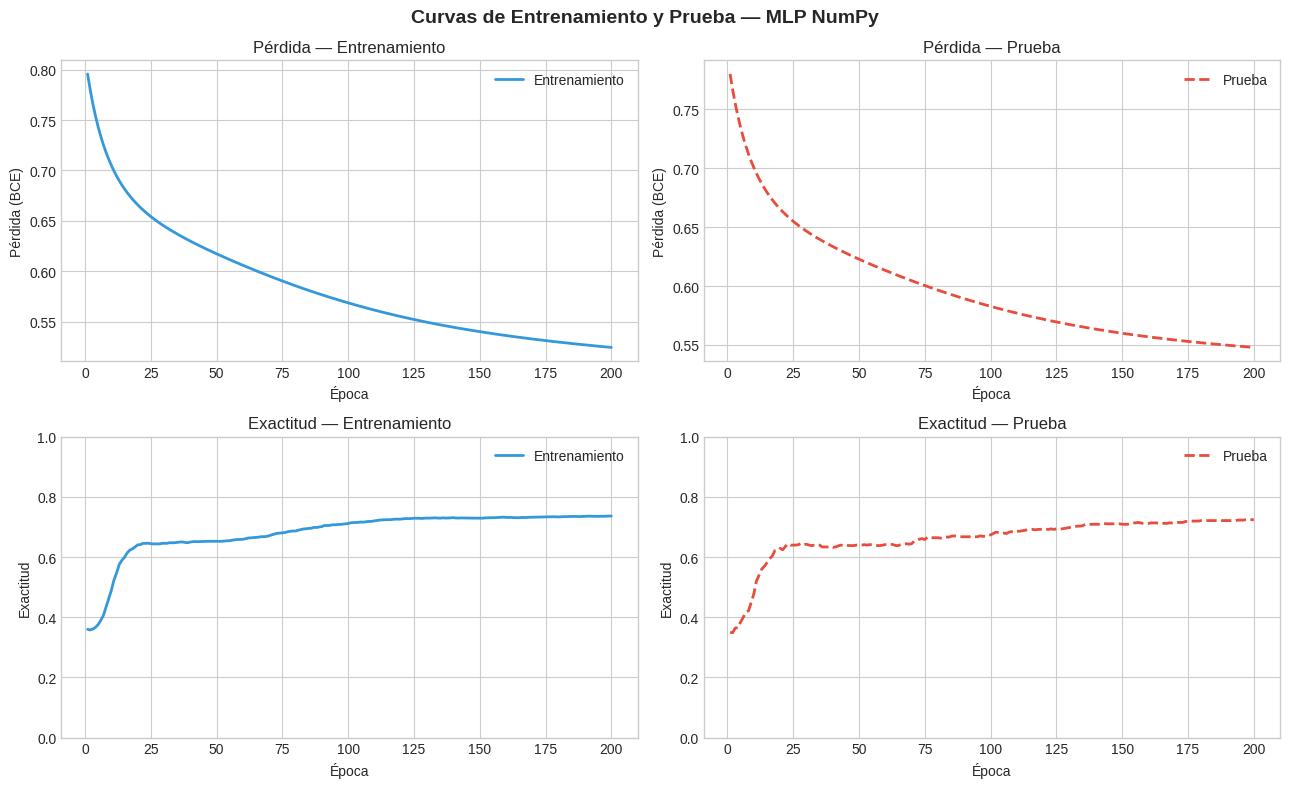

In [12]:
# ¿Qué hace este bloque?
# Graficamos las 4 curvas de aprendizaje en una figura 2x2.

epocas = range(1, len(historial_perdida) + 1)

figura, ejes = plt.subplots(2, 2, figsize=(13, 8))
figura.suptitle("Curvas de Entrenamiento y Prueba — MLP NumPy",
                fontsize=14, fontweight="bold")

# [fila 0, col 0] Pérdida en Entrenamiento
ejes[0, 0].plot(epocas, historial_perdida, color="#3498db", lw=2, label="Entrenamiento")
ejes[0, 0].set_xlabel("Época")
ejes[0, 0].set_ylabel("Pérdida (BCE)")
ejes[0, 0].set_title("Pérdida — Entrenamiento")
ejes[0, 0].legend()
ejes[0, 0].grid(True)

# [fila 0, col 1] Pérdida en Prueba
ejes[0, 1].plot(epocas, historial_perdida_val,
                color="#e74c3c", lw=2, linestyle="--", label="Prueba")
ejes[0, 1].set_xlabel("Época")
ejes[0, 1].set_ylabel("Pérdida (BCE)")
ejes[0, 1].set_title("Pérdida — Prueba")
ejes[0, 1].legend()
ejes[0, 1].grid(True)

# [fila 1, col 0] Exactitud en Entrenamiento
ejes[1, 0].plot(epocas, historial_exactitud, color="#3498db", lw=2, label="Entrenamiento")
ejes[1, 0].set_xlabel("Época")
ejes[1, 0].set_ylabel("Exactitud")
ejes[1, 0].set_title("Exactitud — Entrenamiento")
ejes[1, 0].set_ylim(0, 1)
ejes[1, 0].legend()
ejes[1, 0].grid(True)

# [fila 1, col 1] Exactitud en Prueba
ejes[1, 1].plot(epocas, historial_exactitud_val,
                color="#e74c3c", lw=2, linestyle="--", label="Prueba")
ejes[1, 1].set_xlabel("Época")
ejes[1, 1].set_ylabel("Exactitud")
ejes[1, 1].set_title("Exactitud — Prueba")
ejes[1, 1].set_ylim(0, 1)
ejes[1, 1].legend()
ejes[1, 1].grid(True)

plt.tight_layout()
plt.show()


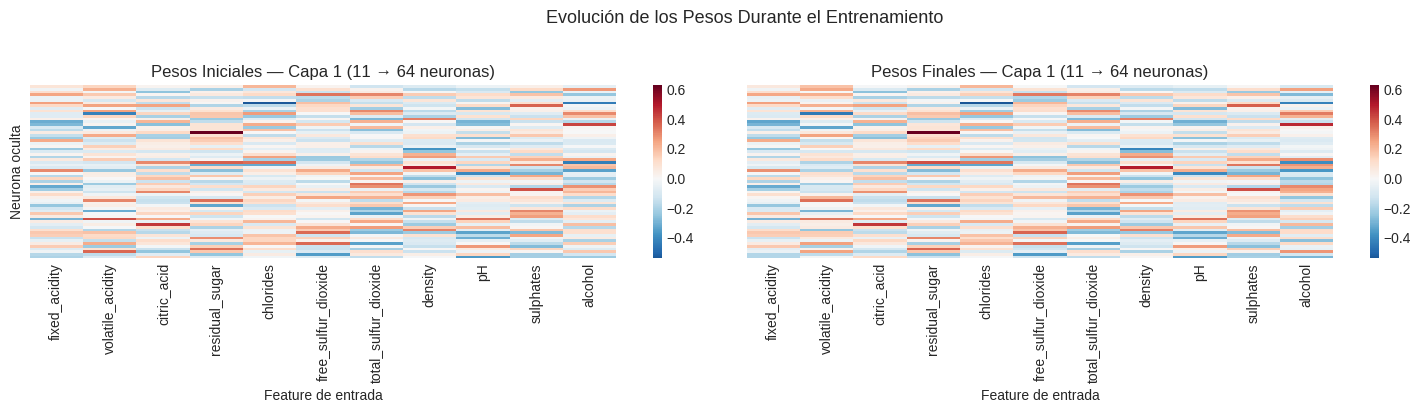

In [13]:
# ¿Qué hace este bloque?
# Comparamos los pesos de la primera capa ANTES y DESPUÉS del entrenamiento.
# Los colores muestran qué features aprendió a considerar importantes la red.
# Un color intenso (rojo o azul) indica que ese peso influyó mucho en el aprendizaje.

pesos_finales_W1 = mlp_np.W[0].copy()

# Usamos la misma escala de colores en ambos heatmaps para comparar justamente
valor_minimo = min(pesos_iniciales_W1.min(), pesos_finales_W1.min())
valor_maximo = max(pesos_iniciales_W1.max(), pesos_finales_W1.max())

figura, ejes = plt.subplots(1, 2, figsize=(15, 4))

# Heatmap izquierdo: pesos antes del entrenamiento (casi todos cercanos a cero)
sns.heatmap(pesos_iniciales_W1.T, ax=ejes[0], cmap="RdBu_r", center=0,
            vmin=valor_minimo, vmax=valor_maximo,
            xticklabels=feature_names, yticklabels=False)
ejes[0].set_title("Pesos Iniciales — Capa 1 (11 → 64 neuronas)")
ejes[0].set_xlabel("Feature de entrada")
ejes[0].set_ylabel("Neurona oculta")

# Heatmap derecho: pesos después del entrenamiento (patrones más marcados)
sns.heatmap(pesos_finales_W1.T, ax=ejes[1], cmap="RdBu_r", center=0,
            vmin=valor_minimo, vmax=valor_maximo,
            xticklabels=feature_names, yticklabels=False)
ejes[1].set_title("Pesos Finales — Capa 1 (11 → 64 neuronas)")
ejes[1].set_xlabel("Feature de entrada")

plt.suptitle("Evolución de los Pesos Durante el Entrenamiento", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
# FASE 2 — Red Fully Connected con PyTorch

## ¿Qué vamos a aprender aquí?

Ahora que entendemos cómo funciona una red neuronal por dentro, vamos a usar **PyTorch**,
que hace automáticamente todo lo que construimos a mano en la Fase 1.

Las ventajas principales de PyTorch:
- **Autograd**: calcula los gradientes automáticamente — no más backprop manual.
- **GPU**: puede entrenar en tarjetas gráficas para acelerar todo.
- **Modularidad**: construimos redes como bloques de LEGO con `nn.Module`.
- **Optimizadores avanzados**: Adam, RMSprop y muchos más con una sola línea.

También introducimos dos técnicas nuevas:
- **Dropout**: durante el entrenamiento, "apaga" neuronas aleatoriamente para evitar sobreajuste.
- **Batch Normalization**: normaliza las activaciones dentro de la red para estabilizar el entrenamiento.


In [14]:
# ¿Qué hace este bloque?
# Preparamos los datos en el formato que espera PyTorch.
# Un DataLoader divide los datos en mini-lotes (batches) y los baraja en cada época.
# Esto hace el entrenamiento más estable que procesar todos los datos de golpe.

class WineDataset(Dataset):
    """Envuelve los arrays de numpy en el formato que entiende PyTorch."""

    def __init__(self, X, y):
        # Convertimos de numpy a tensores de PyTorch (el tipo de dato nativo de PyTorch)
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        """Devuelve cuántas muestras tiene el dataset."""
        return len(self.X)

    def __getitem__(self, indice):
        """Devuelve un par (features, etiqueta) para el índice dado."""
        return self.X[indice], self.y[indice]


# Proporciones de la división
PROP_ENTRENAMIENTO = 0.70
PROP_VALIDACION    = 0.15
PROP_PRUEBA        = 0.15
TAMANO_LOTE        = 32   # Número de muestras que procesa la red a la vez

# División en tres conjuntos (usamos los mismos índices para clf y reg → comparación justa)
todos_los_indices_pt = np.arange(len(X_np))

indices_temporales_pt, indices_prueba_pt = train_test_split(
    todos_los_indices_pt, test_size=PROP_PRUEBA, random_state=42, stratify=y_clf)

proporcion_val_del_resto = PROP_VALIDACION / (PROP_ENTRENAMIENTO + PROP_VALIDACION)
indices_entren_pt, indices_val_pt = train_test_split(
    indices_temporales_pt, test_size=proporcion_val_del_resto,
    random_state=42, stratify=y_clf[indices_temporales_pt])

# Subconjuntos de features
X_train_pt = X_np[indices_entren_pt]
X_val_pt   = X_np[indices_val_pt]
X_test_pt  = X_np[indices_prueba_pt]

# Normalizamos: StandardScaler aprende media y desviación SOLO del entrenamiento
normalizador_pt = StandardScaler()
X_entren_norm  = normalizador_pt.fit_transform(X_train_pt).astype(np.float32)
X_val_norm     = normalizador_pt.transform(X_val_pt).astype(np.float32)
X_prueba_norm  = normalizador_pt.transform(X_test_pt).astype(np.float32)

# Etiquetas para clasificación binaria
y_clf_train = y_clf[indices_entren_pt]
y_clf_val   = y_clf[indices_val_pt]
y_clf_test  = y_clf[indices_prueba_pt]

# Etiquetas para regresión (score continuo)
y_reg_train = y_reg[indices_entren_pt]
y_reg_val   = y_reg[indices_val_pt]
y_reg_test  = y_reg[indices_prueba_pt]

# Datasets y DataLoaders para clasificación
dataset_entren_clf = WineDataset(X_entren_norm, y_clf_train)
dataset_val_clf    = WineDataset(X_val_norm,    y_clf_val)
dataset_prueba_clf = WineDataset(X_prueba_norm, y_clf_test)
train_dl_clf = DataLoader(dataset_entren_clf, batch_size=TAMANO_LOTE, shuffle=True)
val_dl_clf   = DataLoader(dataset_val_clf,   batch_size=TAMANO_LOTE)
test_dl_clf  = DataLoader(dataset_prueba_clf, batch_size=TAMANO_LOTE)

# Datasets y DataLoaders para regresión
dataset_entren_reg = WineDataset(X_entren_norm, y_reg_train)
dataset_val_reg    = WineDataset(X_val_norm,    y_reg_val)
dataset_prueba_reg = WineDataset(X_prueba_norm, y_reg_test)
train_dl_reg = DataLoader(dataset_entren_reg, batch_size=TAMANO_LOTE, shuffle=True)
val_dl_reg   = DataLoader(dataset_val_reg,   batch_size=TAMANO_LOTE)
test_dl_reg  = DataLoader(dataset_prueba_reg, batch_size=TAMANO_LOTE)

# Alias en inglés para compatibilidad con celdas posteriores
X_test_sc  = X_prueba_norm
X_train_sc = X_entren_norm
X_val_sc   = X_val_norm

print(f"Entrenamiento: {len(dataset_entren_clf)}  Validación: {len(dataset_val_clf)}  Prueba: {len(dataset_prueba_clf)}")


Entrenamiento: 4547  Validación: 975  Prueba: 975


## 2.1 Clasificación Binaria con PyTorch

Vamos a predecir si un vino es **bueno** (1) o **malo** (0):

$$\text{Entrada}(11) \to \underbrace{\text{Linear}(64) \to \text{ReLU} \to \text{Dropout}(0.3)}_{\text{capa oculta 1}} \to \underbrace{\text{Linear}(32) \to \text{ReLU}}_{\text{capa oculta 2}} \to \text{Linear}(1) \to \sigma$$

**Ingredientes del entrenamiento:**
- **Loss BCE**: mide qué tan equivocadas son las predicciones de probabilidad.
- **Optimizador Adam**: actualiza pesos adaptando la tasa de aprendizaje por parámetro.
- **Early Stopping**: para automáticamente si el error de validación no mejora en 15 épocas seguidas.
  Esto previene el sobreajuste sin tener que fijar el número exacto de épocas.


In [15]:
# ¿Qué hace este bloque?
# Definimos la arquitectura de la red (MLPClasificador) y la función de entrenamiento.
# La función registra pérdida y exactitud en entrenamiento Y validación en cada época.

class MLPClasificador(nn.Module):
    """Red neuronal para clasificar vinos como buenos (1) o malos (0).
    El Dropout evita que la red memorice los datos de entrenamiento."""

    def __init__(self, probabilidad_dropout=0.3):
        """probabilidad_dropout: fracción de neuronas que se apagan aleatoriamente durante el entrenamiento."""
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(11, 64),                       # Capa 1: 11 entradas → 64 neuronas
            nn.ReLU(),                               # Activación
            nn.Dropout(probabilidad_dropout),        # Apaga neuronas al azar (regularización)
            nn.Linear(64, 32),                       # Capa 2: 64 → 32 neuronas
            nn.ReLU(),                               # Activación
            nn.Linear(32, 1),                        # Salida: una sola neurona
            nn.Sigmoid(),                            # Convierte a probabilidad (0 a 1)
        )

    def forward(self, x):
        """Pasa los datos por todas las capas y devuelve la probabilidad de ser clase 1."""
        return self.red(x)


def entrenar_clasificador(modelo, train_dl, val_dl,
                          n_epocas=150, lr=0.001, paciencia=15,
                          peso_decay=0.0, verbose=True):
    """Entrena el clasificador con early stopping. Devuelve historial de métricas por época."""

    funcion_perdida = nn.BCELoss()
    optimizador     = optim.Adam(modelo.parameters(), lr=lr, weight_decay=peso_decay)

    mejor_perdida_val   = float("inf")
    contador_sin_mejora = 0
    mejor_estado_red    = None

    # Preparamos tensores completos para evaluación rápida al final de cada época
    X_val_tensor    = val_dl.dataset.X
    y_val_tensor    = val_dl.dataset.y.unsqueeze(1)
    X_entren_tensor = train_dl.dataset.X
    y_entren_tensor = train_dl.dataset.y.unsqueeze(1)

    historial = {"loss_train": [], "loss_val": [], "acc_train": [], "acc_val": []}

    for epoca in range(n_epocas):
        # --- Fase de entrenamiento: ajustamos pesos con mini-lotes ---
        modelo.train()
        perdida_total_entren = 0.0
        for X_lote, y_lote in train_dl:
            y_lote = y_lote.unsqueeze(1)
            optimizador.zero_grad()           # Limpiamos los gradientes anteriores
            perdida = funcion_perdida(modelo(X_lote), y_lote)
            perdida.backward()               # Calculamos gradientes
            optimizador.step()               # Actualizamos pesos
            perdida_total_entren += perdida.item()

        # --- Fase de evaluación: calculamos métricas sin actualizar pesos ---
        modelo.eval()
        with torch.no_grad():
            prediccion_val    = modelo(X_val_tensor)
            perdida_val       = funcion_perdida(prediccion_val, y_val_tensor).item()
            exactitud_val     = ((prediccion_val >= 0.5).float() == y_val_tensor).float().mean().item()

            prediccion_entren = modelo(X_entren_tensor)
            exactitud_entren  = ((prediccion_entren >= 0.5).float() == y_entren_tensor).float().mean().item()

        historial["loss_train"].append(perdida_total_entren / len(train_dl))
        historial["loss_val"].append(perdida_val)
        historial["acc_train"].append(exactitud_entren)
        historial["acc_val"].append(exactitud_val)

        # --- Early stopping ---
        if perdida_val < mejor_perdida_val:
            mejor_perdida_val   = perdida_val
            contador_sin_mejora = 0
            mejor_estado_red    = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            contador_sin_mejora += 1
            if contador_sin_mejora >= paciencia:
                if verbose:
                    print(f"  Early stopping en época {epoca+1}  "
                          f"(mejor pérdida val={mejor_perdida_val:.4f})")
                break

        if verbose and (epoca + 1) % 30 == 0:
            print(f"  Época {epoca+1:3d} | pérdida_entren={historial['loss_train'][-1]:.4f} "
                  f"| pérdida_val={perdida_val:.4f} | exactitud_val={exactitud_val:.4f}")

    # Restauramos los pesos del mejor momento encontrado
    if mejor_estado_red:
        modelo.load_state_dict(mejor_estado_red)
    return historial


print("Entrenando MLPClasificador... esto puede tardar unos segundos.")
clf_modelo = MLPClasificador(probabilidad_dropout=0.3)
hist_clf   = entrenar_clasificador(clf_modelo, train_dl_clf, val_dl_clf,
                                   n_epocas=150, paciencia=15)
print("¡Entrenamiento del clasificador completado!")


Entrenando MLPClasificador... esto puede tardar unos segundos.
  Época  30 | pérdida_entren=0.4781 | pérdida_val=0.4527 | exactitud_val=0.7815
  Época  60 | pérdida_entren=0.4663 | pérdida_val=0.4466 | exactitud_val=0.7938
  Época  90 | pérdida_entren=0.4419 | pérdida_val=0.4380 | exactitud_val=0.8031
  Early stopping en época 99  (mejor pérdida val=0.4346)
¡Entrenamiento del clasificador completado!


### ¿Qué observar en estas curvas?

Compara las curvas de **entrenamiento** (azul sólido) contra las de **prueba** (rojo discontinuo):

- **Ideal**: ambas curvas bajan juntas (pérdida) o suben juntas (exactitud) y se mantienen cercanas.
- **Sobreajuste**: la curva de entrenamiento mejora mucho pero la de prueba se estanca o empeora.
- **El Dropout** que tiene este modelo ayuda a que las dos curvas se mantengan cercanas entre sí,
  porque obliga a la red a no depender demasiado de ninguna neurona en particular.

> Si ves que la exactitud de prueba se detiene antes que la de entrenamiento,
> es señal de sobreajuste. El early stopping detiene el entrenamiento justo en ese punto.


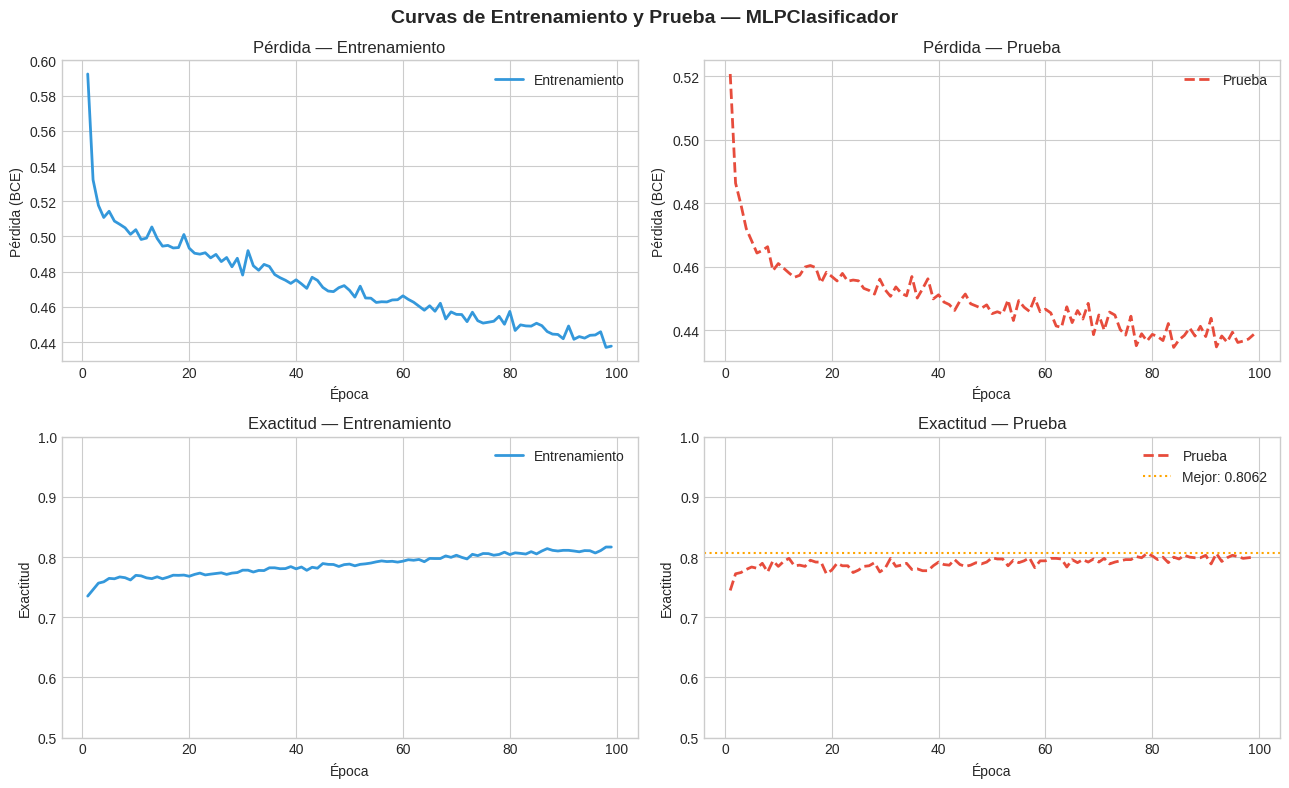

In [16]:
# ¿Qué hace este bloque?
# Graficamos las 4 curvas de aprendizaje del clasificador en formato 2x2.

epocas_clf = range(1, len(hist_clf["loss_train"]) + 1)

figura, ejes = plt.subplots(2, 2, figsize=(13, 8))
figura.suptitle("Curvas de Entrenamiento y Prueba — MLPClasificador",
                fontsize=14, fontweight="bold")

ejes[0, 0].plot(epocas_clf, hist_clf["loss_train"], color="#3498db", lw=2, label="Entrenamiento")
ejes[0, 0].set_xlabel("Época")
ejes[0, 0].set_ylabel("Pérdida (BCE)")
ejes[0, 0].set_title("Pérdida — Entrenamiento")
ejes[0, 0].legend()
ejes[0, 0].grid(True)

ejes[0, 1].plot(epocas_clf, hist_clf["loss_val"],
                color="#e74c3c", lw=2, linestyle="--", label="Prueba")
ejes[0, 1].set_xlabel("Época")
ejes[0, 1].set_ylabel("Pérdida (BCE)")
ejes[0, 1].set_title("Pérdida — Prueba")
ejes[0, 1].legend()
ejes[0, 1].grid(True)

ejes[1, 0].plot(epocas_clf, hist_clf["acc_train"], color="#3498db", lw=2, label="Entrenamiento")
ejes[1, 0].set_xlabel("Época")
ejes[1, 0].set_ylabel("Exactitud")
ejes[1, 0].set_title("Exactitud — Entrenamiento")
ejes[1, 0].set_ylim(0.5, 1.0)
ejes[1, 0].legend()
ejes[1, 0].grid(True)

ejes[1, 1].plot(epocas_clf, hist_clf["acc_val"],
                color="#e74c3c", lw=2, linestyle="--", label="Prueba")
ejes[1, 1].axhline(max(hist_clf["acc_val"]), color="orange", ls=":", lw=1.5,
                   label=f"Mejor: {max(hist_clf['acc_val']):.4f}")
ejes[1, 1].set_xlabel("Época")
ejes[1, 1].set_ylabel("Exactitud")
ejes[1, 1].set_title("Exactitud — Prueba")
ejes[1, 1].set_ylim(0.5, 1.0)
ejes[1, 1].legend()
ejes[1, 1].grid(True)

plt.tight_layout()
plt.show()


## 2.2 Regresión con PyTorch

Ahora en lugar de clasificar "bueno/malo", vamos a predecir el **score numérico exacto** (0-10).

Arquitectura:
$$\text{Entrada}(11) \to \text{Linear}(64) \to \text{ReLU} \to \underbrace{\text{BatchNorm1d}(64)}_{\text{normaliza activaciones}} \to \text{Linear}(32) \to \text{ReLU} \to \text{Linear}(1)$$

**Sin activación en la salida**: porque queremos un número real cualquiera, no solo (0, 1).

**Batch Normalization**: normaliza las activaciones dentro de cada capa mini-lote a mini-lote.
Esto estabiliza el entrenamiento y permite tasas de aprendizaje más altas.

- **Loss MSE**: $\mathcal{L}_{MSE} = \frac{1}{m}\sum_i(\hat{y}_i - y_i)^2$ — penaliza más los errores grandes.
- **Optimizador Adam** con $\alpha = 0.001$.


In [17]:
# ¿Qué hace este bloque?
# Definimos la red regresora y su función de entrenamiento.
# Para la "exactitud" usamos un truco: redondeamos la predicción al entero más cercano
# y comparamos con el valor real redondeado — así podemos graficarla igual que en clasificación.

class MLPRegresor(nn.Module):
    """Red neuronal para predecir el score de calidad como número continuo.
    Usa Batch Normalization para estabilizar el entrenamiento."""

    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(11, 64),     # Capa 1: 11 entradas → 64 neuronas
            nn.ReLU(),
            nn.BatchNorm1d(64),    # Normaliza las activaciones → entrenamiento más estable
            nn.Linear(64, 32),     # Capa 2: 64 → 32 neuronas
            nn.ReLU(),
            nn.Linear(32, 1),      # Salida: un solo número (el score predicho)
            # Sin activación final: queremos cualquier valor real, no limitado a (0, 1)
        )

    def forward(self, x):
        """Pasa los datos por la red y devuelve el score de calidad predicho."""
        return self.red(x)


def entrenar_regresor(modelo, train_dl, val_dl, optimizador,
                      n_epocas=150, paciencia=15, verbose=True):
    """Entrena el regresor con early stopping. Devuelve historial de pérdida y exactitud.
    La exactitud redondea predicciones al entero más cercano para poder visualizarla."""

    funcion_perdida = nn.MSELoss()

    mejor_perdida_val   = float("inf")
    contador_sin_mejora = 0
    mejor_estado_red    = None

    X_val_tensor    = val_dl.dataset.X
    y_val_tensor    = val_dl.dataset.y.unsqueeze(1)
    X_entren_tensor = train_dl.dataset.X
    y_entren_tensor = train_dl.dataset.y.unsqueeze(1)

    historial = {"loss_train": [], "loss_val": [], "acc_train": [], "acc_val": []}

    for epoca in range(n_epocas):
        # --- Fase de entrenamiento ---
        modelo.train()
        perdida_total_entren = 0.0
        for X_lote, y_lote in train_dl:
            y_lote = y_lote.unsqueeze(1)
            optimizador.zero_grad()
            perdida = funcion_perdida(modelo(X_lote), y_lote)
            perdida.backward()
            optimizador.step()
            perdida_total_entren += perdida.item()

        # --- Fase de evaluación ---
        modelo.eval()
        with torch.no_grad():
            perdida_val = funcion_perdida(modelo(X_val_tensor), y_val_tensor).item()

            # Exactitud: ¿predicción redondeada == valor real redondeado?
            exactitud_val    = (torch.round(modelo(X_val_tensor))
                                == torch.round(y_val_tensor)).float().mean().item()
            exactitud_entren = (torch.round(modelo(X_entren_tensor))
                                == torch.round(y_entren_tensor)).float().mean().item()

        historial["loss_train"].append(perdida_total_entren / len(train_dl))
        historial["loss_val"].append(perdida_val)
        historial["acc_train"].append(exactitud_entren)
        historial["acc_val"].append(exactitud_val)

        if perdida_val < mejor_perdida_val:
            mejor_perdida_val   = perdida_val
            contador_sin_mejora = 0
            mejor_estado_red    = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            contador_sin_mejora += 1
            if contador_sin_mejora >= paciencia:
                if verbose:
                    print(f"  Early stopping en época {epoca+1}  "
                          f"(mejor pérdida val={mejor_perdida_val:.4f})")
                break

        if verbose and (epoca + 1) % 30 == 0:
            print(f"  Época {epoca+1:3d} | pérdida_entren={historial['loss_train'][-1]:.4f} "
                  f"| pérdida_val={perdida_val:.4f}")

    if mejor_estado_red:
        modelo.load_state_dict(mejor_estado_red)
    return historial


print("Entrenando MLPRegresor... esto puede tardar unos segundos.")
reg_modelo   = MLPRegresor()
opt_reg_main = optim.Adam(reg_modelo.parameters(), lr=0.001)
hist_reg     = entrenar_regresor(reg_modelo, train_dl_reg, val_dl_reg,
                                 opt_reg_main, n_epocas=150, paciencia=15)
print("¡Entrenamiento del regresor completado!")


Entrenando MLPRegresor... esto puede tardar unos segundos.
  Época  30 | pérdida_entren=0.4839 | pérdida_val=0.4744
  Early stopping en época 50  (mejor pérdida val=0.4588)
¡Entrenamiento del regresor completado!


### ¿Qué observar en estas curvas?

Para la regresión, la "exactitud" se calcula redondeando la predicción al entero más cercano.
No esperes valores tan altos como en clasificación — predecir un número exacto es más difícil.

- **Pérdida (MSE)**: debe bajar. Valores más bajos = predicciones más cercanas al score real.
- **Exactitud redondeada**: qué fracción de predicciones coinciden al redondear al entero más próximo.
- Si la pérdida de prueba crece mientras la de entrenamiento baja → sobreajuste.

> El scatter plot que sigue muestra qué tan cerca están las predicciones del valor real.
> Los puntos idealmente deberían caer sobre la línea diagonal roja (predicción perfecta).


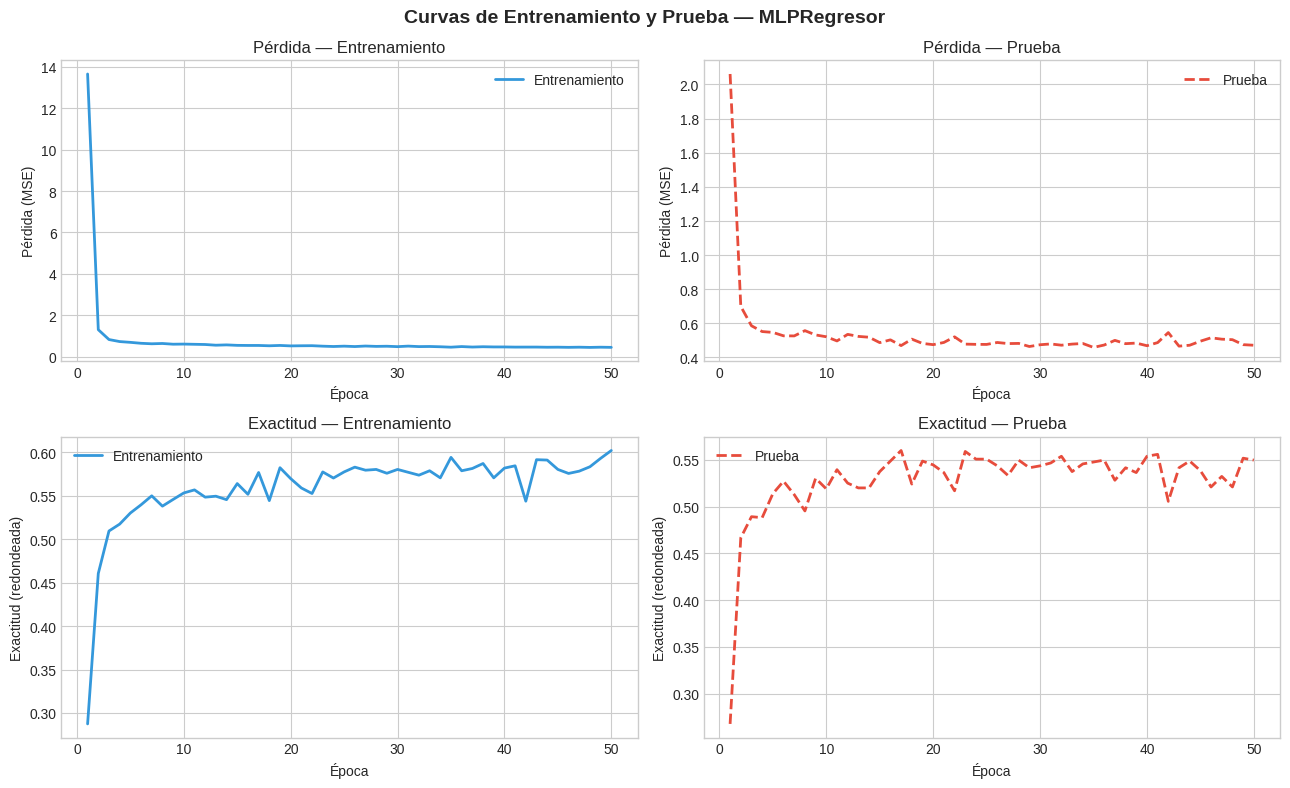

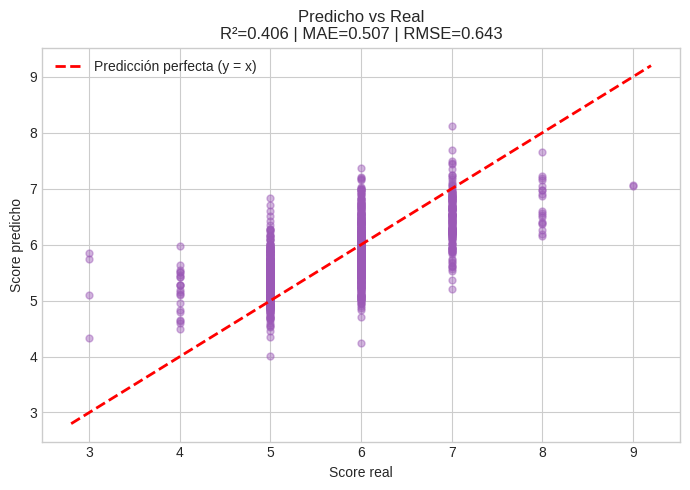

In [18]:
# ¿Qué hace este bloque?
# Graficamos las 4 curvas de aprendizaje del regresor y un scatter predicho vs real.

epocas_reg = range(1, len(hist_reg["loss_train"]) + 1)

# --- Figura 1: Curvas 2x2 ---
figura, ejes = plt.subplots(2, 2, figsize=(13, 8))
figura.suptitle("Curvas de Entrenamiento y Prueba — MLPRegresor",
                fontsize=14, fontweight="bold")

ejes[0, 0].plot(epocas_reg, hist_reg["loss_train"], color="#3498db", lw=2, label="Entrenamiento")
ejes[0, 0].set_xlabel("Época")
ejes[0, 0].set_ylabel("Pérdida (MSE)")
ejes[0, 0].set_title("Pérdida — Entrenamiento")
ejes[0, 0].legend()
ejes[0, 0].grid(True)

ejes[0, 1].plot(epocas_reg, hist_reg["loss_val"],
                color="#e74c3c", lw=2, linestyle="--", label="Prueba")
ejes[0, 1].set_xlabel("Época")
ejes[0, 1].set_ylabel("Pérdida (MSE)")
ejes[0, 1].set_title("Pérdida — Prueba")
ejes[0, 1].legend()
ejes[0, 1].grid(True)

ejes[1, 0].plot(epocas_reg, hist_reg["acc_train"], color="#3498db", lw=2, label="Entrenamiento")
ejes[1, 0].set_xlabel("Época")
ejes[1, 0].set_ylabel("Exactitud (redondeada)")
ejes[1, 0].set_title("Exactitud — Entrenamiento")
ejes[1, 0].legend()
ejes[1, 0].grid(True)

ejes[1, 1].plot(epocas_reg, hist_reg["acc_val"],
                color="#e74c3c", lw=2, linestyle="--", label="Prueba")
ejes[1, 1].set_xlabel("Época")
ejes[1, 1].set_ylabel("Exactitud (redondeada)")
ejes[1, 1].set_title("Exactitud — Prueba")
ejes[1, 1].legend()
ejes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --- Figura 2: Scatter predicho vs real ---
reg_modelo.eval()
with torch.no_grad():
    y_pred_reg_test = reg_modelo(torch.FloatTensor(X_test_sc)).numpy().flatten()

r2_main   = r2_score(y_reg_test, y_pred_reg_test)
mae_main  = mean_absolute_error(y_reg_test, y_pred_reg_test)
rmse_main = float(np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test)))

figura2, eje2 = plt.subplots(figsize=(7, 5))
eje2.scatter(y_reg_test, y_pred_reg_test, alpha=0.45, color="#9b59b6", s=25)
rango = [min(y_reg_test.min(), y_pred_reg_test.min()) - 0.2,
         max(y_reg_test.max(), y_pred_reg_test.max()) + 0.2]
eje2.plot(rango, rango, "r--", lw=2, label="Predicción perfecta (y = x)")
eje2.set_xlabel("Score real")
eje2.set_ylabel("Score predicho")
eje2.set_title(f"Predicho vs Real\nR²={r2_main:.3f} | MAE={mae_main:.3f} | RMSE={rmse_main:.3f}")
eje2.legend()
plt.tight_layout()
plt.show()


=== Reporte de Clasificación — Conjunto de Prueba ===

              precision    recall  f1-score   support

    Malo (0)       0.71      0.68      0.70       358
   Bueno (1)       0.82      0.84      0.83       617

    accuracy                           0.78       975
   macro avg       0.77      0.76      0.76       975
weighted avg       0.78      0.78      0.78       975



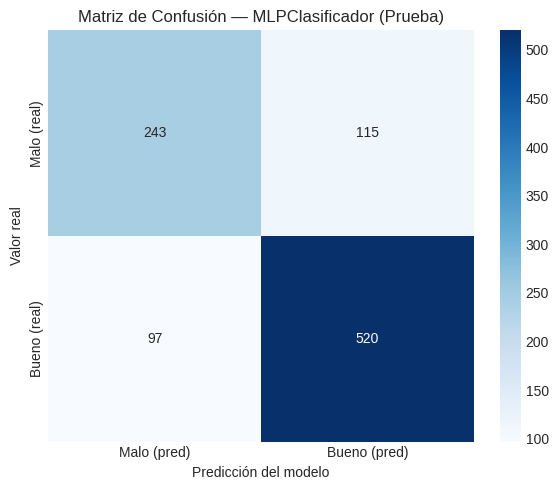

In [19]:
# ¿Qué hace este bloque?
# Evaluación final del clasificador en el conjunto de prueba.
# El reporte muestra precisión, recall y F1-score para cada clase.
# La matriz de confusión muestra exactamente dónde se equivoca el modelo.

clf_modelo.eval()
with torch.no_grad():
    X_prueba_tensor        = torch.FloatTensor(X_test_sc)
    probabilidades_prueba  = clf_modelo(X_prueba_tensor).numpy().flatten()
    predicciones_prueba    = (probabilidades_prueba >= 0.5).astype(int)

etiquetas_prueba_int = y_clf_test.astype(int)

print("=== Reporte de Clasificación — Conjunto de Prueba ===\n")
print(classification_report(etiquetas_prueba_int, predicciones_prueba,
                             target_names=["Malo (0)", "Bueno (1)"]))

# La matriz de confusión muestra:
#   [Malos correctos   | Malos clasificados como buenos]
#   [Buenos como malos | Buenos correctos              ]
figura, eje = plt.subplots(figsize=(6, 5))
matriz_conf = confusion_matrix(etiquetas_prueba_int, predicciones_prueba)
sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", ax=eje,
            xticklabels=["Malo (pred)", "Bueno (pred)"],
            yticklabels=["Malo (real)", "Bueno (real)"])
eje.set_title("Matriz de Confusión — MLPClasificador (Prueba)")
eje.set_xlabel("Predicción del modelo")
eje.set_ylabel("Valor real")
plt.tight_layout()
plt.show()


In [20]:
# ¿Qué hace este bloque?
# Mostramos las métricas del regresor en el conjunto de prueba en una tabla clara.
# R²: cuánta variabilidad del score explicamos (1.0 = perfecto, 0 = no explica nada).
# MAE: error promedio en puntos de score (ej: MAE=0.5 → nos equivocamos medio punto).
# RMSE: como el MAE pero penaliza más los errores grandes.

print("=== Métricas de Regresión — Conjunto de Prueba ===\n")
tabla_metricas = pd.DataFrame({
    "Métrica": ["R² (coef. de determinación)",
                "MAE (error absoluto medio)",
                "RMSE (raíz del error cuadrático)"],
    "Valor": [f"{r2_main:.4f}", f"{mae_main:.4f}", f"{rmse_main:.4f}"],
    "¿Qué significa?": [
        f"Explicamos el {r2_main:.1%} de la variación en la calidad",
        f"En promedio nos equivocamos ±{mae_main:.3f} puntos en el score",
        f"Desviación típica del error: {rmse_main:.3f} puntos",
    ],
})
display(tabla_metricas.set_index("Métrica"))


=== Métricas de Regresión — Conjunto de Prueba ===



,Valor,¿Qué significa?
Métrica,,
R² (coef. de determinación),0.4056,Explicamos el 40.6% de la variación en la calidad
MAE (error absoluto medio),0.5068,En promedio nos equivocamos ±0.507 puntos en e...
RMSE (raíz del error cuadrático),0.6429,Desviación típica del error: 0.643 puntos


---
# FASE 3 — Mejoras y Comparación

## ¿Qué vamos a aprender aquí?

Ya tenemos modelos que funcionan. Ahora vamos a experimentar sistemáticamente con
diferentes decisiones de diseño para entender cuáles mejoran los resultados.

Es como tener una receta que funciona y probar variaciones controladas:
¿qué pasa si cambio el horno? ¿Qué pasa si añado un ingrediente extra?

### 3.1 Regularización — ¿Cómo evitamos el sobreajuste?

Entrenamos tres versiones del clasificador con diferentes técnicas:

| Técnica | ¿Qué hace? |
|---------|-----------|
| Sin regularización | Modelo base de referencia |
| **Dropout($p$)** | Apaga neuronas al azar en cada paso de entrenamiento |
| **L2 / Weight Decay** | Penaliza pesos muy grandes: $\mathcal{L}_{total} = \mathcal{L}_{BCE} + \lambda \|W\|_2^2$ |

**En palabras simples:** L2 le dice a la red "no uses pesos demasiado grandes" añadiendo
un costo extra al error. Dropout le dice "no te apoyes siempre en las mismas neuronas".

### 3.2 Optimizadores — ¿Cómo aprende más rápido la red?

| Optimizador | Idea principal |
|-------------|---------------|
| SGD + momentum | $v_t = \beta v_{t-1} + \nabla\mathcal{L},\ W \leftarrow W - \alpha v_t$ — añade "inercia" |
| Adam | Combina momentum con ajuste automático de la tasa de aprendizaje — el más usado hoy |
| RMSprop | Normaliza por la magnitud reciente del gradiente para evitar pasos desiguales |


Entrenando modelo sin regularización...
Entrenando modelo con Dropout(0.4)...
Entrenando modelo con regularización L2 (weight_decay=1e-4)...

¡Comparación completada! Graficando resultados...


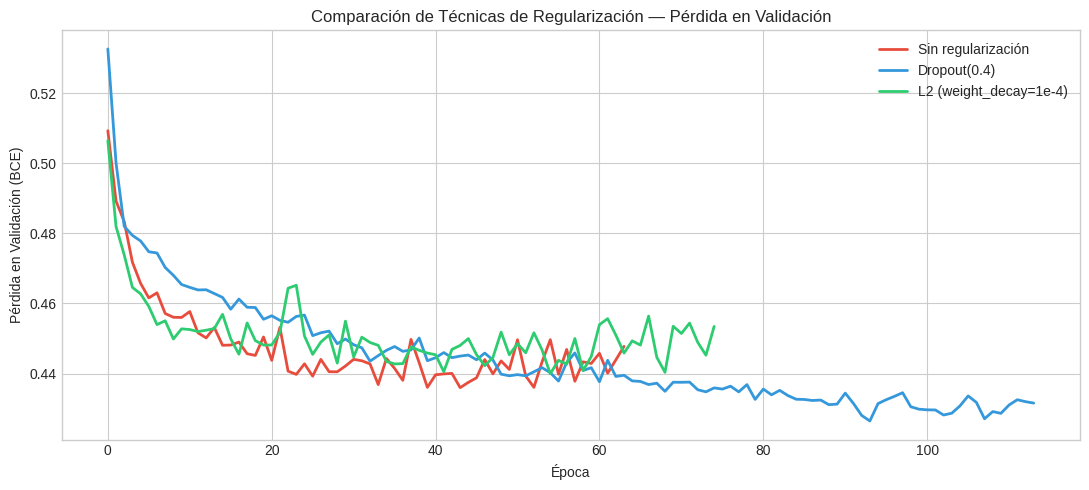

In [21]:
# ¿Qué hace este bloque?
# Entrenamos tres variantes del clasificador con distintas técnicas de regularización.
# Luego comparamos sus curvas de pérdida en validación para ver cuál generaliza mejor.

EPOCAS_COMPARACION    = 120
PACIENCIA_COMPARACION = 20

print("Entrenando modelo sin regularización...")
clf_sin_reg  = MLPClasificador(probabilidad_dropout=0.0)
hist_sin_reg = entrenar_clasificador(clf_sin_reg, train_dl_clf, val_dl_clf,
                                     n_epocas=EPOCAS_COMPARACION,
                                     paciencia=PACIENCIA_COMPARACION, verbose=False)

print("Entrenando modelo con Dropout(0.4)...")
clf_dropout  = MLPClasificador(probabilidad_dropout=0.4)
hist_dropout = entrenar_clasificador(clf_dropout, train_dl_clf, val_dl_clf,
                                     n_epocas=EPOCAS_COMPARACION,
                                     paciencia=PACIENCIA_COMPARACION, verbose=False)

print("Entrenando modelo con regularización L2 (weight_decay=1e-4)...")
clf_l2  = MLPClasificador(probabilidad_dropout=0.0)
hist_l2 = entrenar_clasificador(clf_l2, train_dl_clf, val_dl_clf,
                                n_epocas=EPOCAS_COMPARACION,
                                paciencia=PACIENCIA_COMPARACION,
                                peso_decay=1e-4, verbose=False)

print("\n¡Comparación completada! Graficando resultados...")

# Comparación de la pérdida en validación para los tres modelos
figura, eje = plt.subplots(figsize=(11, 5))
eje.plot(hist_sin_reg["loss_val"], label="Sin regularización", color="#e74c3c", lw=2)
eje.plot(hist_dropout["loss_val"], label="Dropout(0.4)",       color="#3498db", lw=2)
eje.plot(hist_l2["loss_val"],      label="L2 (weight_decay=1e-4)", color="#2ecc71", lw=2)
eje.set_xlabel("Época")
eje.set_ylabel("Pérdida en Validación (BCE)")
eje.set_title("Comparación de Técnicas de Regularización — Pérdida en Validación")
eje.legend()
plt.tight_layout()
plt.show()


In [22]:
# ¿Qué hace este bloque?
# Calculamos la exactitud de cada modelo en el conjunto de prueba y la mostramos
# en una tabla para comparar los tres enfoques de regularización.

def exactitud_en_prueba(modelo):
    """Calcula la exactitud del clasificador en el conjunto de prueba final."""
    modelo.eval()
    with torch.no_grad():
        predicciones = (modelo(torch.FloatTensor(X_test_sc)) >= 0.5).float().numpy().flatten()
    return float(np.mean(predicciones == y_clf_test))

exactitud_sin_reg = exactitud_en_prueba(clf_sin_reg)
exactitud_dropout = exactitud_en_prueba(clf_dropout)
exactitud_l2      = exactitud_en_prueba(clf_l2)

tabla_regularizacion = pd.DataFrame({
    "Modelo":             ["Sin regularización", "Dropout(0.4)", "L2 (weight_decay=1e-4)"],
    "Mejor Val Loss":     [f"{min(hist_sin_reg['loss_val']):.4f}",
                           f"{min(hist_dropout['loss_val']):.4f}",
                           f"{min(hist_l2['loss_val']):.4f}"],
    "Exactitud Prueba":   [f"{exactitud_sin_reg:.4f}",
                           f"{exactitud_dropout:.4f}",
                           f"{exactitud_l2:.4f}"],
    "Épocas entrenadas":  [len(hist_sin_reg["loss_val"]),
                           len(hist_dropout["loss_val"]),
                           len(hist_l2["loss_val"])],
})
print("=== Tabla Comparativa — Técnicas de Regularización ===")
display(tabla_regularizacion)


=== Tabla Comparativa — Técnicas de Regularización ===


,Modelo,Mejor Val Loss,Exactitud Prueba,Épocas entrenadas
0,Sin regularización,0.4360,0.7631,64
1,Dropout(0.4),0.4265,0.7908,114
2,L2 (weight_decay=1e-4),0.4399,0.7815,75


Entrenando con SGD + momentum...
Entrenando con Adam...
Entrenando con RMSprop...

¡Comparación completada! Graficando resultados...


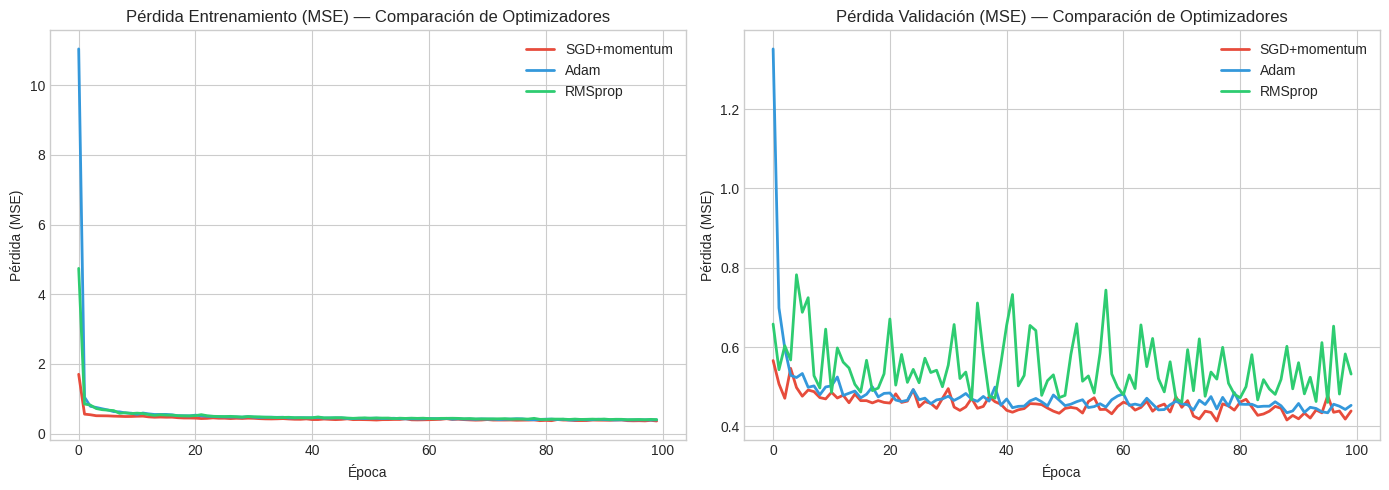

In [23]:
# ¿Qué hace este bloque?
# Comparamos tres optimizadores entrenando el regresor durante 100 épocas fijas.
# Al fijar el número de épocas, podemos ver claramente cuál converge más rápido.

EPOCAS_OPTIMIZADORES = 100

print("Entrenando con SGD + momentum...")
reg_sgd  = MLPRegresor()
hist_sgd = entrenar_regresor(
    reg_sgd, train_dl_reg, val_dl_reg,
    optim.SGD(reg_sgd.parameters(), lr=0.01, momentum=0.9),
    n_epocas=EPOCAS_OPTIMIZADORES, paciencia=EPOCAS_OPTIMIZADORES, verbose=False)

print("Entrenando con Adam...")
reg_adam      = MLPRegresor()
hist_adam_cmp = entrenar_regresor(
    reg_adam, train_dl_reg, val_dl_reg,
    optim.Adam(reg_adam.parameters(), lr=0.001),
    n_epocas=EPOCAS_OPTIMIZADORES, paciencia=EPOCAS_OPTIMIZADORES, verbose=False)

print("Entrenando con RMSprop...")
reg_rms  = MLPRegresor()
hist_rms = entrenar_regresor(
    reg_rms, train_dl_reg, val_dl_reg,
    optim.RMSprop(reg_rms.parameters(), lr=0.001),
    n_epocas=EPOCAS_OPTIMIZADORES, paciencia=EPOCAS_OPTIMIZADORES, verbose=False)

print("\n¡Comparación completada! Graficando resultados...")

# Comparación de convergencia: pérdida en entrenamiento y validación para los tres optimizadores
figura, ejes = plt.subplots(1, 2, figsize=(14, 5))
colores_opt     = {"SGD+momentum": "#e74c3c", "Adam": "#3498db", "RMSprop": "#2ecc71"}
historiales_opt = {"SGD+momentum": hist_sgd, "Adam": hist_adam_cmp, "RMSprop": hist_rms}

for nombre, historial in historiales_opt.items():
    ejes[0].plot(historial["loss_train"], label=nombre, color=colores_opt[nombre], lw=2)
    ejes[1].plot(historial["loss_val"],   label=nombre, color=colores_opt[nombre], lw=2)

for eje, titulo in zip(ejes, ["Pérdida Entrenamiento (MSE)", "Pérdida Validación (MSE)"]):
    eje.set_xlabel("Época")
    eje.set_ylabel("Pérdida (MSE)")
    eje.set_title(f"{titulo} — Comparación de Optimizadores")
    eje.legend()

plt.tight_layout()
plt.show()


In [24]:
# ¿Qué hace este bloque?
# Calculamos R², MAE y RMSE para cada regresor entrenado con distinto optimizador
# y los comparamos en una tabla.

def metricas_regresor_en_prueba(modelo):
    """Calcula R², MAE y RMSE en el conjunto de prueba para un regresor."""
    modelo.eval()
    with torch.no_grad():
        predicciones = modelo(torch.FloatTensor(X_test_sc)).numpy().flatten()
    return (r2_score(y_reg_test, predicciones),
            mean_absolute_error(y_reg_test, predicciones),
            float(np.sqrt(mean_squared_error(y_reg_test, predicciones))))

r2_sgd,  mae_sgd,  rmse_sgd  = metricas_regresor_en_prueba(reg_sgd)
r2_adam, mae_adam, rmse_adam = metricas_regresor_en_prueba(reg_adam)
r2_rms,  mae_rms,  rmse_rms  = metricas_regresor_en_prueba(reg_rms)

tabla_optimizadores = pd.DataFrame({
    "Optimizador":    ["SGD + momentum(0.9)", "Adam(lr=0.001)", "RMSprop(lr=0.001)"],
    "Val Loss Final": [f"{hist_sgd['loss_val'][-1]:.4f}",
                       f"{hist_adam_cmp['loss_val'][-1]:.4f}",
                       f"{hist_rms['loss_val'][-1]:.4f}"],
    "R²":   [f"{r2_sgd:.4f}",   f"{r2_adam:.4f}",   f"{r2_rms:.4f}"],
    "MAE":  [f"{mae_sgd:.4f}",  f"{mae_adam:.4f}",  f"{mae_rms:.4f}"],
    "RMSE": [f"{rmse_sgd:.4f}", f"{rmse_adam:.4f}", f"{rmse_rms:.4f}"],
})
print("=== Tabla Comparativa — Optimizadores (Regresión) ===")
display(tabla_optimizadores)


=== Tabla Comparativa — Optimizadores (Regresión) ===


,Optimizador,Val Loss Final,R²,MAE,RMSE
0,SGD + momentum(0.9),0.4389,0.4492,0.4913,0.6189
1,Adam(lr=0.001),0.4531,0.4405,0.4882,0.6237
2,RMSprop(lr=0.001),0.5318,0.4132,0.4983,0.6388


---
# Resumen y Conclusiones

## Tabla Comparativa Global

| Fase | Modelo | Tarea | Regularización | Optimizador | Métrica principal |
|------|--------|-------|----------------|-------------|---------|
| 1 | MLPNumpy (manual) | Clasificación | Ninguna | SGD lr=0.05 | Exactitud |
| 2 | MLPClasificador | Clasificación | Dropout(0.3) | Adam lr=0.001 | Exactitud + F1 |
| 2 | MLPRegresor | Regresión | BatchNorm | Adam lr=0.001 | R², MAE, RMSE |
| 3 | MLPClasificador ×3 | Clasificación | Sin / Dropout / L2 | Adam lr=0.001 | Exactitud |
| 3 | MLPRegresor ×3 | Regresión | BatchNorm | SGD / Adam / RMSprop | R², RMSE |

## Conclusiones

### Sobre Clasificación
- El **Dropout** reduce el sobreajuste al obligar a la red a no depender de ninguna neurona en particular.
  Generalmente supera al modelo sin regularización cuando hay diferencia entre curvas de entrenamiento y prueba.
- La **regularización L2** (weight decay) produce una curva de validación más suave.
  Es útil cuando el modelo oscila mucho o cuando el dataset es pequeño.

### Sobre Regresión
- **Adam** converge más rápido y con mayor estabilidad en las primeras épocas,
  gracias a que adapta automáticamente la tasa de aprendizaje por parámetro.
- **RMSprop** llega a resultados similares a Adam en datasets de tamaño medio.
- **SGD + momentum** puede competir pero necesita más épocas y mayor ajuste del learning rate.

## Las 5 reglas de oro del entrenamiento de redes neuronales

1. **Normaliza siempre tus datos**: sin normalización el entrenamiento es inestable o no converge.
2. **Usa early stopping**: detiene el entrenamiento en el momento óptimo automáticamente.
3. **Inicializa bien los pesos** (Xavier/Glorot): garantiza que los gradientes fluyan correctamente.
4. **Lee las curvas de aprendizaje**: diferencia grande entre entrenamiento y prueba → sobreajuste;
   ambas altas → subajuste.
5. **Adam es tu punto de partida**: para la mayoría de problemas tabulares, Adam con lr=0.001 funciona bien.

## Próximos Pasos

Si quieres seguir aprendiendo, estos son los temas naturales que siguen:
- Arquitecturas más profundas con *residual connections* (redes que "saltan" capas).
- *Learning Rate Scheduling*: ajustar la tasa de aprendizaje durante el entrenamiento.
- Búsqueda automática de hiperparámetros con **Optuna**.
- Combinar varios modelos (*ensemble*) para predicciones más robustas.
